In [209]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open('names.txt', 'r').read().splitlines()
words

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [8]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [166]:
def build_dataset(words):
    block_size = 3 # 3 chars to predict 4th

    X, Y = [],[]
    for w in words:
        context = [0] * block_size
        # print(context)
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # 1: to crop and append only last 3 
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [38]:
C = torch.randn(27,2) #embedding matrix, 27 chars, 2 dim embedding

In [39]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [63]:
W1 = torch.randn((6,100)) # each column, 1 neuron
B1 = torch.randn(100)

In [50]:
torch.unbind(emb,1) # what this does is along the index 1 dimension (along each of our first 3 characters), we pick up the embeddings across all training samples

(tensor([[ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [ 0.6781,  0.0674],
         [ 1.6788,  0.2223],
         [ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [-0.3411,  1.8494],
         [-0.1812, -1.0220],
         [-0.4379, -1.1596],
         [ 0.0532,  1.4314],
         [ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [ 1.7757,  0.1444],
         [ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [-0.4379, -1.1596],
         [ 0.7316,  0.9652],
         [ 1.7757,  0.1444],
         [-2.0074, -0.5877],
         [ 0.6781,  0.0674],
         [-0.1812, -1.0220],
         [ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [ 0.7316,  0.9652],
         [-0.3411,  1.8494],
         [ 0.9947,  0.6629],
         [ 1.1593,  0.8476]]),
 tensor([[ 0.2916, -0.1317],
         [ 0.2916, -0.1317],
         [ 0

In [66]:
torch.cat(torch.unbind(emb,1), 1).shape # this is to merge the 3 character embeddings into a single value. Each row is a single value. 
# 1 here signifies merging across rows (entry 1 of list 1, entry 1 of list 2, etc.)
# ineffiectient as it creates new memory

torch.Size([32, 6])

In [57]:
# in pytorch the storage is always a 1D vector
# can use .view to reorganise C[X] than use above transforms

emb.view(32,6).shape

torch.Size([32, 6])

In [96]:
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + B1)
# the +b1 will add the same set of values to first neuron, same set to second, etc. How? Pytorch flatennign and expansion when one dimension is missing
h.shape
# tanh to get value b/w 0 and 1

torch.Size([32, 100])

In [79]:
# layer 2
W2 = torch.randn(100, 27)
B2 = torch.randn(27)

In [80]:
logits = h @ W2 + B2

In [81]:
logits.shape

torch.Size([32, 27])

In [83]:
logits

tensor([[ 4.1688e+00,  6.1495e-01, -7.4654e+00, -3.0004e+00, -1.2975e+01,
          9.9327e+00, -1.8646e+00,  2.7341e+00, -1.2805e+01,  5.7868e+00,
         -3.3434e+00, -1.1535e+01, -1.3961e+01,  7.7826e+00,  7.1322e+00,
          4.2323e+00,  1.1640e+01,  1.4754e+01,  6.3002e+00, -8.0534e+00,
         -4.8219e+00,  1.9513e+00,  3.6733e+00, -1.4617e+00,  1.0648e+01,
          3.5880e+00,  2.9477e+00],
        [ 1.5690e+00,  1.7298e+00, -9.3243e+00, -5.2100e+00, -1.4333e+01,
          1.6740e+01, -1.3157e+00, -7.0301e-01, -1.1995e+01,  2.2911e+00,
         -8.1772e+00, -8.3007e+00, -9.7263e+00,  5.0369e+00,  3.0251e+00,
          6.1036e+00,  9.4006e+00,  1.4499e+01,  1.0426e+01, -5.0324e+00,
         -4.8104e+00,  7.6597e-02,  5.8279e+00,  2.8033e+00,  1.1075e+01,
          2.8016e+00,  7.3360e-01],
        [-6.3135e+00,  3.0414e+00, -7.0633e+00, -7.4099e+00, -1.1244e+01,
          1.5901e+01, -2.4246e+00, -4.4186e+00, -5.6291e+00,  4.1045e-03,
         -1.2132e+01, -1.4612e+00, -3.97

In [94]:
counts = logits.exp()
counts.shape

torch.Size([32, 27])

In [95]:
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([32, 27])

In [93]:
prob[torch.arange(32), Y] # will give probability of for each row (training sample), probablitiy that next character is Y

tensor([7.5234e-03, 7.4362e-06, 2.1130e-08, 1.1005e-07, 4.6127e-16, 2.5162e-05,
        1.1392e-08, 2.3357e-04, 2.9521e-09, 3.9818e-07, 1.4066e-11, 6.9835e-01,
        6.7570e-07, 2.3979e-05, 7.8663e-04, 1.4281e-14, 1.1909e-04, 2.6787e-13,
        2.0469e-12, 9.2733e-12, 2.1770e-11, 1.1390e-10, 2.5784e-10, 2.8533e-05,
        4.5898e-07, 1.1618e-10, 9.3285e-06, 2.7768e-07, 1.9376e-06, 1.7035e-08,
        6.5595e-10, 4.5686e-01])

In [108]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.7697)

In [236]:
# Summary code

g = torch.Generator().manual_seed(2147483647)
C = torch.randn(27,10, generator = g) #Embedding matrix
w1 = torch.randn(30,200, generator = g) #Weights for first 100 neuron layer
b1 = torch.randn(200, generator = g) #bias for 100 newurons
w2 = torch.randn(200,27, generator = g) #Weights for first 100 neuron layer
b2 = torch.randn(27, generator = g) #bias for 100 newurons
parameters = [C, w1,b1,w2,b2]

In [237]:
for p in parameters:
    p.requires_grad = True

In [238]:
lre = torch.linspace(-3,0,1000)
lrs = 10 ** lre

In [239]:
lri = []
lossi = []
stepi = []


In [241]:

for i in range(50000):
    # Forward pass
    ix = torch.randint(0, Xtr.shape[0], [32,])
    emb = C[Xtr[ix]] # embedding
    h = torch.tanh(emb.view(-1,30) @ w1 + b1) #first layer output
    logits = h @ w2 + b2 # second layer output
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims = True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    
    # Using above is very ineffiecient due to new memory being created
    # also if any is very positive, will result in inf
    # below function solves this by smoothening the function by subtracting all by max value
    
    
    
    loss = F.cross_entropy(logits, Ytr[ix]) # use this rather than do the negative log likelihood repeat
    # backward
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(i)
    lossi.append(loss.log10().item())
    # To determine -0.1 -> Experiment between min and max
    # limspace to get values between min and max. Find out from there what is ideal value

print(loss.item())

2.2132041454315186


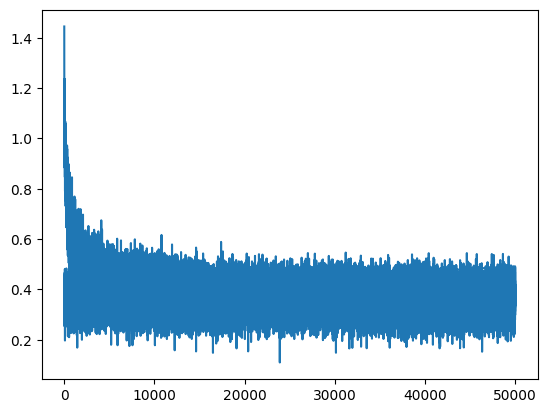

In [242]:
plt.plot(stepi, lossi)
# meaningless as we keep going

In [ ]:
# RESULT CHECKING

In [243]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ w1 + b1) #first layer output
logits = h @ w2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss

# closer dev and test loss means not overfitting

tensor(2.3051, grad_fn=<NllLossBackward0>)

In [ ]:
# SAMPLING

In [250]:
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range (20):
    out = []
    context= [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # first dim is 1 cause only 1 sample we gettting
        h = torch.tanh(emb.view(1,-1) @ w1 + b1) 
        logits = h @ w2 + b2 
        probs = F.softmax(logits, dim =1)
        # why?
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print("".join(itos[i] for i in out))

carmah.
amorilli.
kimori.
tatel.
kansen.
jazonelfordyah.
alanei.
aramara.
corihvik.
levell.
amondin.
quint.
salin.
alianni.
oluwal.
aiarinix.
kael.
ivell.
emmi.
oiv.


tensor(2.2969, grad_fn=<NllLossBackward0>)

In [ ]:
# Below iwhtouit batching

In [ ]:
for i in range(10):
    # Forward pass
    
    emb = C[X] # embedding
    h = torch.tanh(emb.view(-1,6) @ w1 + b1) #first layer output
    logits = h @ w2 + b2 # second layer output
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims = True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    
    # Using above is very ineffiecient due to new memory being created
    # also if any is very positive, will result in inf
    # below function solves this by smoothening the function by subtracting all by max value
    
    
    
    loss = F.cross_entropy(logits, Y) # use this rather than do the negative log likelihood repeat
    # backward
    print(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.1 * p.grad